# E-Commerce Collaborative Filtering Recommendation System

**Pipeline:**
1. Load & explore the raw event data
2. Understand purchase frequency and sparsity (why we need to filter)
3. Filter to active users/products and build a lightweight product lookup table
4. Build the sparse user-item interaction matrix
5. Item-based CF: find similar products from co-purchase patterns (Nearest Neighbors, cosine)
6. Matrix factorization (Truncated SVD): learn latent user & item factors for user-based CF
7. Write `recommend_similar_items()` and `recommend_for_user()` and demo both
8. Visualize the interaction data (purchase distributions, sparsity)



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

Load the Dataset

In [3]:
df = pd.read_csv('kz.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (434799, 8)


,event_time,order_id,product_id,category_id,category_code,brand,price,user_id
0,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2268105426648170900,electronics.tablet,samsung,162.01,1515915625441993984
1,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2268105426648170900,electronics.tablet,samsung,162.01,1515915625441993984
2,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2268105430162997728,electronics.audio.headphone,huawei,77.52,1515915625447879434
3,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2268105430162997728,electronics.audio.headphone,huawei,77.52,1515915625447879434
4,2020-04-26 08:45:57 UTC,2295716521449619559,1515966223509261697,2268105442636858090,furniture.kitchen.table,maestro,39.33,1515915625450382722


Dataset checking

In [4]:
print(df.info())
print("\nMissing values:\n", df.isna().sum())
print(f"\nUnique users    : {df['user_id'].nunique():,}")
print(f"Unique products : {df['product_id'].nunique():,}")
print(f"Unique orders   : {df['order_id'].nunique():,}")
print(f"Date range      : {df['event_time'].min()}  ->  {df['event_time'].max()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434799 entries, 0 to 434798
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     434799 non-null  object 
 1   order_id       434799 non-null  int64  
 2   product_id     434799 non-null  int64  
 3   category_id    434799 non-null  int64  
 4   category_code  434799 non-null  object 
 5   brand          420718 non-null  object 
 6   price          434799 non-null  float64
 7   user_id        434799 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 26.5+ MB
None

Missing values:
 event_time           0
order_id             0
product_id           0
category_id          0
category_code        0
brand            14081
price                0
user_id              0
dtype: int64

Unique users    : 206,679
Unique products : 12,325
Unique orders   : 338,744
Date range      : 1970-01-01 00:33:40 UTC  ->  2020-11-21 10:10:30 UTC


Check Purchase Frequency per User & per Product (Sparsity)

In [5]:
user_counts = df['user_id'].value_counts()
prod_counts = df['product_id'].value_counts()

print("Purchases per user:")
print(user_counts.describe())
print("\nPurchases per product:")
print(prod_counts.describe())

full_density = df.shape[0] / (df['user_id'].nunique() * df['product_id'].nunique()) * 100
print(f"\nFull user-item matrix density: {full_density:.5f}%  (extremely sparse)")

Purchases per user:
count    206679.000000
mean          2.103741
std           2.799327
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         184.000000
Name: count, dtype: float64

Purchases per product:
count    12325.000000
mean        35.277809
std        110.215124
min          1.000000
25%          2.000000
50%          6.000000
75%         26.000000
max       2759.000000
Name: count, dtype: float64

Full user-item matrix density: 0.01707%  (extremely sparse)


Filter to Active Users & Products

In [6]:
MIN_USER_PURCHASES = 3
MIN_PRODUCT_PURCHASES = 5

active_users = user_counts[user_counts >= MIN_USER_PURCHASES].index
active_products = prod_counts[prod_counts >= MIN_PRODUCT_PURCHASES].index

interactions = df[
    df['user_id'].isin(active_users) & df['product_id'].isin(active_products)
].copy()

print(f"Interactions kept: {len(interactions):,} of {len(df):,} ({len(interactions)/len(df):.1%})")
print(f"Active users   : {interactions['user_id'].nunique():,}")
print(f"Active products: {interactions['product_id'].nunique():,}")

Interactions kept: 224,652 of 434,799 (51.7%)
Active users   : 44,324
Active products: 6,974


Product Lookup Table

In [7]:
product_info = (
    df.groupby('product_id')
      .agg(
          category_code=('category_code', 'first'),
          brand=('brand', lambda s: s.mode().iat[0] if not s.mode().empty else 'unknown'),
          price=('price', 'mean'),
      )
      .reset_index()
)
product_info['brand'] = product_info['brand'].fillna('unknown').str.lower().str.strip()
product_info['price'] = product_info['price'].round(2)
product_info = product_info.set_index('product_id')

product_info.head()

,category_code,brand,price
product_id,,,
1515966223509088493,electronics.smartphone,apple,740.72
1515966223509088496,apparel.glove,xbox,266.18
1515966223509088497,electronics.smartphone,samsung,1215.25
1515966223509088498,electronics.smartphone,samsung,115.72
1515966223509088499,computers.notebook,lenovo,601.83


Encode IDs & Build the Sparse User-Item Matrix


In [8]:
users = pd.Index(sorted(interactions['user_id'].unique()), name='user_id')
prods = pd.Index(sorted(interactions['product_id'].unique()), name='product_id')

user_to_idx = pd.Series(np.arange(len(users)), index=users)
prod_to_idx = pd.Series(np.arange(len(prods)), index=prods)

rows = interactions['product_id'].map(prod_to_idx).values
cols = interactions['user_id'].map(user_to_idx).values
data = np.ones(len(interactions), dtype=np.float32)

item_user = csr_matrix((data, (rows, cols)), shape=(len(prods), len(users)))
density = 100 * item_user.nnz / (item_user.shape[0] * item_user.shape[1])

print(f"item-user matrix shape: {item_user.shape}  (products x users)")
print(f"Density: {density:.4f}%  |  Non-zero entries: {item_user.nnz:,}")

item-user matrix shape: (6974, 44324)  (products x users)
Density: 0.0575%  |  Non-zero entries: 177,872


Item-Based CF: Fit Nearest Neighbors on Co-Purchase Patterns


In [9]:
item_nn = NearestNeighbors(metric='cosine', algorithm='brute')
item_nn.fit(item_user)

print("Item-based model fitted on", item_user.shape[0], "products.")

Item-based model fitted on 6974 products.


The `recommend_similar_items()` Function

In [10]:
def recommend_similar_items(product_id, top_n=10):
    if product_id not in prod_to_idx.index:
        raise ValueError(f"product_id {product_id} not found in the filtered interaction matrix")

    idx = prod_to_idx[product_id]
    distances, indices = item_nn.kneighbors(item_user[idx], n_neighbors=top_n + 1)

    rec_ids = prods[indices[0]]
    result = product_info.loc[rec_ids].copy()
    result['product_id'] = rec_ids
    result['similarity'] = 1 - distances[0]
    result = result[result['product_id'] != product_id]  # exclude the query product itself

    cols = ['product_id', 'category_code', 'brand', 'price', 'similarity']
    return result[cols].reset_index(drop=True)

Demo: Item-Based Recommendations ("Customers Who Bought This Also Bought...")

In [11]:
# Pick a product with plenty of co-purchase history so the demo is meaningful
demo_product_id = prod_counts.loc[prods].sort_values(ascending=False).index[0]

query_product = product_info.loc[[demo_product_id]].reset_index()
print("Query product:")
display(query_product)

print("\nTop 10 products frequently bought by the same customers:")
recommend_similar_items(demo_product_id, top_n=10)

Query product:


,product_id,category_code,brand,price
0,1515966223517846928,electronics.smartphone,samsung,173.59



Top 10 products frequently bought by the same customers:


,product_id,category_code,brand,price,similarity
0,1515966223517846980,electronics.smartphone,samsung,173.59,0.165178
1,1515966223517846906,electronics.smartphone,samsung,173.59,0.114970
2,1515966223510174551,electronics.smartphone,samsung,208.31,0.106807
3,1515966223509106786,electronics.smartphone,samsung,138.87,0.101079
4,1515966223522710798,electronics.smartphone,samsung,138.87,0.098910
5,1515966223509088521,electronics.smartphone,samsung,115.72,0.091504
6,2273948319124291598,electronics.tablet,apple,719.88,0.089002
7,2388434452475833969,computers.notebook,lenovo,416.64,0.069255
8,1515966223522710797,electronics.smartphone,samsung,138.87,0.066081
9,1515966223530620259,electronics.smartphone,xiaomi,254.61,0.065892


Matrix Factorization with Truncated SVD

In [12]:
N_COMPONENTS = 30

user_item = item_user.T.tocsr()  # users x products

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
user_factors = svd.fit_transform(user_item)   # users x components
item_factors = svd.components_.T              # products x components

print(f"user_factors shape: {user_factors.shape}")
print(f"item_factors shape: {item_factors.shape}")
print(f"Explained variance (top {N_COMPONENTS} components): {svd.explained_variance_ratio_.sum():.1%}")

user_factors shape: (44324, 30)
item_factors shape: (6974, 30)
Explained variance (top 30 components): 17.7%


The `recommend_for_user()` Function

In [13]:
purchased_by_user = interactions.groupby('user_id')['product_id'].apply(set)

def recommend_for_user(user_id, top_n=10):
    if user_id not in user_to_idx.index:
        raise ValueError(f"user_id {user_id} not found in the filtered interaction matrix")

    u_idx = user_to_idx[user_id]
    scores = user_factors[u_idx] @ item_factors.T          # predicted score per product

    already_bought = purchased_by_user.get(user_id, set())
    already_idx = prod_to_idx[list(already_bought)].values
    scores[already_idx] = -np.inf                            # never re-recommend a past purchase

    top_idx = np.argpartition(-scores, top_n)[:top_n]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    rec_ids = prods[top_idx]
    result = product_info.loc[rec_ids].copy()
    result['product_id'] = rec_ids
    result['predicted_score'] = scores[top_idx]

    cols = ['product_id', 'category_code', 'brand', 'price', 'predicted_score']
    return result[cols].reset_index(drop=True)

Demo: Personalized Recommendations for a User

In [14]:
# Pick a user with a decent purchase history so the demo is meaningful
history_sizes = purchased_by_user.apply(len)
demo_user_id = history_sizes[history_sizes >= 5].index[0]

print("Demo user:", demo_user_id)
print("\nPurchase history:")
display(product_info.loc[list(purchased_by_user[demo_user_id])].reset_index())

print("\nTop 10 personalized recommendations:")
recommend_for_user(demo_user_id, top_n=10)

Demo user: 1515915625440051468

Purchase history:


,product_id,category_code,brand,price
0,2388434452474083105,electronics.telephone,panasonic,30.53
1,2273948310777627555,apparel.glove,xbox,335.63
2,2388434452475938474,electronics.smartphone,apple,1145.81
3,2388434452474147979,electronics.audio.headphone,xiaomi,30.07
4,1515966223522710798,electronics.smartphone,samsung,138.87
5,2388434452476036590,electronics.smartphone,apple,1435.16
6,2335421146742129424,electronics.video.tv,samsung,428.22
7,1515966223509104210,electronics.video.tv,ava,115.72
8,2388434452476036593,electronics.smartphone,apple,1435.16
9,2388434452475528535,electronics.audio.headphone,xiaomi,28.91



Top 10 personalized recommendations:


,product_id,category_code,brand,price,predicted_score
0,1515966223517846928,electronics.smartphone,samsung,173.59,0.080595
1,1515966223509088521,electronics.smartphone,samsung,115.72,0.056737
2,1515966223510419555,appliances.environment.vacuum,bork,41.41,0.054941
3,1515966223509089067,electronics.smartphone,samsung,138.87,0.053550
4,1515966223509088628,electronics.smartphone,samsung,856.46,0.036477
5,1515966223509089514,electronics.smartphone,samsung,254.61,0.033971
6,1515966223509089373,apparel.glove,sony,403.45,0.032248
7,1515966223517993795,electronics.smartphone,samsung,231.46,0.026965
8,1515966223509088532,electronics.smartphone,samsung,300.90,0.026908
9,1515966223509104944,electronics.smartphone,samsung,104.14,0.026192


Visualize the Interaction Data

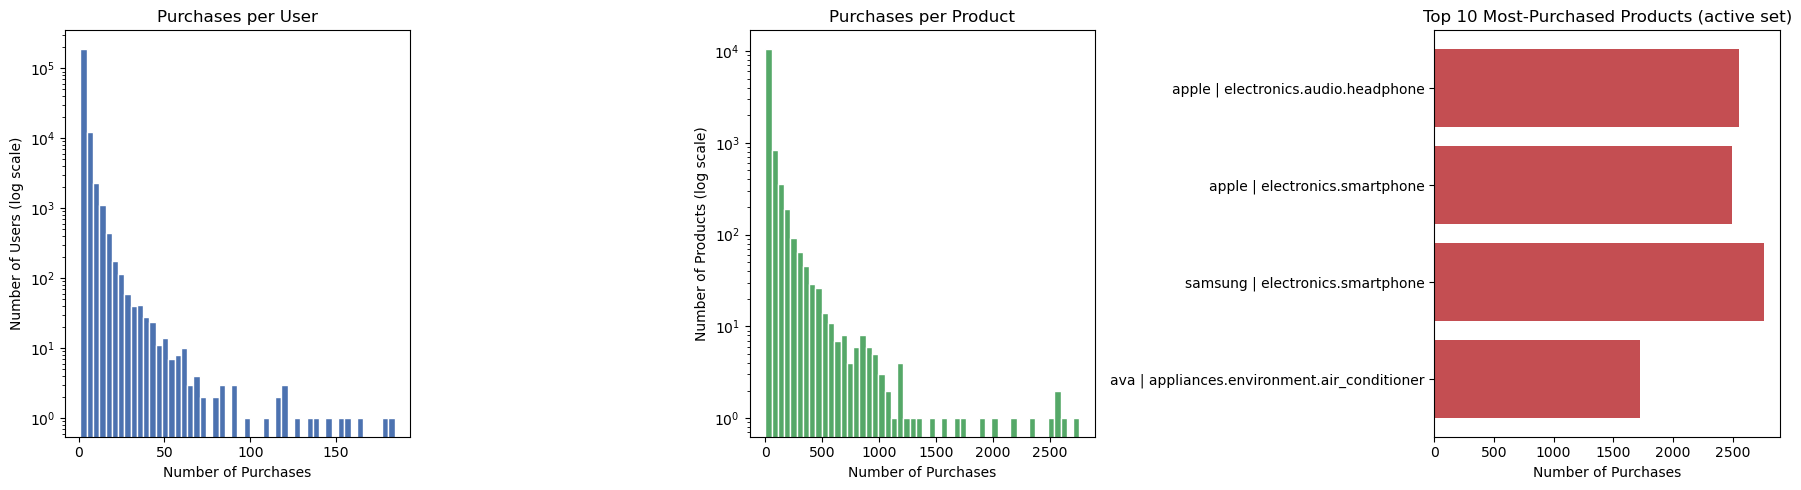

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Purchases per user (log scale - highly skewed)
axes[0].hist(user_counts, bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('Purchases per User')
axes[0].set_xlabel('Number of Purchases')
axes[0].set_ylabel('Number of Users (log scale)')

# Purchases per product (log scale - highly skewed)
axes[1].hist(prod_counts, bins=50, color='#55A868', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Purchases per Product')
axes[1].set_xlabel('Number of Purchases')
axes[1].set_ylabel('Number of Products (log scale)')

# Most co-purchased products (highest activity)
top_products = prod_counts.loc[prods].sort_values(ascending=False).head(10)
top_labels = product_info.loc[top_products.index, 'brand'] + ' | ' + product_info.loc[top_products.index, 'category_code']
axes[2].barh(top_labels[::-1], top_products.values[::-1], color='#C44E52')
axes[2].set_title('Top 10 Most-Purchased Products (active set)')
axes[2].set_xlabel('Number of Purchases')

plt.tight_layout()
plt.show()